In [33]:
# Imports 
import os
import math
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


- Core RMIST-net

In [34]:
#--------------------- forward kernel and adjoint kernel (imaging kernal)

# ----------------------------------------------------------------------
# RMIST‑Net and helper functions (kernel generation, forward/adjoint, network)
# ----------------------------------------------------------------------
def make_rm_kernels(H, W, R, fc=78.3e9, c=3e8, device="cpu"):
    """
    Build RM forward and adjoint kernels φ_r and φ_r^† on (kx, kz) grid.

    S = RM(α) = IFFT2( FFT2(α) * φ_r )
    α = RM^†(S) = IFFT2( FFT2(S) * φ_r^† )

    H, W : image size (rows=z, cols=x)
    R : range slice (scalar)
    """
    # Image-domain coordinates (relative units)
    x = torch.linspace(-W / 2, W / 2, W, device=device)
    z = torch.linspace(-H / 2, H / 2, H, device=device)
    dx = x[1] - x[0]
    dz = z[1] - z[0]

    # Spatial frequency sampling
    dkx = 2 * math.pi / (W * dx)
    dkz = 2 * math.pi / (H * dz)
    kx = torch.linspace(-W / 2, W / 2, W, device=device) * dkx
    kz = torch.linspace(-H / 2, H / 2, H, device=device) * dkz

    # Meshgrid (Kx, Kz)
    Kx, Kz = torch.meshgrid(kx, kz, indexing="xy")
    K0 = 2 * math.pi * fc / c
    K_sq = Kx**2 + Kz**2
    K_check = 4 * (K0**2) - K_sq
    Ky = torch.sqrt(torch.clamp(K_check, min=0.0))

    # Forward kernel φ_r
    Ky_safe = torch.where(Ky == 0, torch.ones_like(Ky), Ky)
    phi = (1.0 / Ky_safe) * torch.exp(-1j * Ky * R)
    phi = torch.where(Ky == 0, torch.zeros_like(phi), phi)

    # Adjoint kernel φ_r^†
    phi_dag = Ky * torch.exp(1j * Ky * R)

    return phi, phi_dag  # each (W, H) complex


def rm_forward(alpha_ri, phi):
    """
    RM forward: S = RM(α)
    alpha_ri : (B, 2, H, W) [Re, Im]
    phi      : (W, H) complex kernel φ_r
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = alpha_ri.shape
    alpha = torch.complex(alpha_ri[:, 0], alpha_ri[:, 1])  # (B,H,W)
    F_alpha = torch.fft.fft2(alpha)

    # Ensure phi is (H, W)
    if phi.shape[0] == W and phi.shape[1] == H:
        phi_hw = phi.permute(1, 0)
    else:
        phi_hw = phi

    S = F_alpha * phi_hw
    s = torch.fft.ifft2(S)
    return torch.stack([s.real, s.imag], dim=1)


def rm_adjoint(s_ri, phi_dag):
    """
    RM adjoint: α = RM^†(S)
    s_ri     : (B, 2, H, W) [Re, Im]
    phi_dag  : (W, H) complex kernel φ_r^†
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = s_ri.shape
    s = torch.complex(s_ri[:, 0], s_ri[:, 1])
    F_s = torch.fft.fft2(s)

    if phi_dag.shape[0] == W and phi_dag.shape[1] == H:
        phi_dag_hw = phi_dag.permute(1, 0)
    else:
        phi_dag_hw = phi_dag

    A = F_s * phi_dag_hw
    a = torch.fft.ifft2(A)
    return torch.stack([a.real, a.imag], dim=1)


# -----------------------------  RMIST-Net
class RMISTPhase(nn.Module):
    """
    One unrolled ISTA phase:
      v_t       = S - RM(α_t)
      r_t       = α_t + τ_t * RM^†(v_t)
      α_{t+1}   = F_st(r_t, θ_t)
    with complex soft-thresholding F_st.
    """

    def __init__(self, phi, phi_dag):
        super().__init__()
        # Fixed physics kernels
        self.register_buffer("phi", phi)
        self.register_buffer("phi_dag", phi_dag)
        # Trainable scalars τ_t, θ_t
        self.tau = nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))
        self.theta = nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))

    def soft_thresh(self, r):
        """
        Complex soft thresholding:
          α_next = r * max(|r| - θ, 0) / |r|
        r : (B, 2, H, W) [Re, Im]
        """
        real = r[:, 0]
        imag = r[:, 1]
        mag = torch.sqrt(real**2 + imag**2 + 1e-12)
        shr = torch.relu(mag - self.theta)  # max(|r|-θ, 0)
        scale = shr / (mag + 1e-12)
        real2 = real * scale
        imag2 = imag * scale
        return torch.stack([real2, imag2], dim=1)

    def forward(self, S_ri, alpha_ri):
        # Stage 1: residual v_t = S - RM(α_t)
        RM_alpha = rm_forward(alpha_ri, self.phi)
        v = S_ri - RM_alpha

        # Stage 2: gradient step r_t = α_t + τ_t * RM^†(v_t)
        grad = rm_adjoint(v, self.phi_dag)
        r = alpha_ri + self.tau * grad

        # Stage 3: shrinkage α_{t+1} = F_st(r_t, θ_t)
        alpha_next = self.soft_thresh(r)
        return alpha_next


class RMISTNet(nn.Module):
    """
    RMIST-Net: T-phase unrolled RM + ISTA sparse reconstruction network.
    """

    def __init__(self, H, W, R, fc=78.3e9, c=3e8, T=6, device="cpu"):
        super().__init__()
        phi, phi_dag = make_rm_kernels(H, W, R, fc, c, device=device)
        self.phases = nn.ModuleList([RMISTPhase(phi, phi_dag) for _ in range(T)])

    def forward(self, S_ri):
        # Initialization: α_0 = RM^†(S)
        alpha = rm_adjoint(S_ri, self.phases[0].phi_dag)

        # Unroll T ISTA phases
        for phase in self.phases:
            alpha = phase(S_ri, alpha)
        return alpha

- RMA (traditional)

In [35]:
import numpy as np
import torch
import torch.nn.functional as F

# ----------------------------------------------------------------------
# RMA focusing from raw time‑domain data (torch implementation)
# ----------------------------------------------------------------------
def rma_torch_matchesMATLAB(sar_data, params_torch):
    """
    MATLAB-matched RMA starting from RAW time-domain data.
    sar_data: (Nsamp, M*N) complex torch tensor

    Returns:
        img_mag     : cropped magnitude image
        img_complex : cropped complex image
    """
    device = sar_data.device

    Nsamp        = params_torch["Nsamp"]
    M            = params_torch["M"]
    N            = params_torch["N"]
    nFFTtime     = params_torch["nFFTtime"]
    k0_range_bin = params_torch["k0_range_bin"]   # 0-based
    nFFTspace    = params_torch["nFFTspace"]
    dx           = params_torch["dx"]
    dy           = params_torch["dy"]
    F0           = params_torch["F0"]
    z0           = params_torch["z0"]             # meters
    bbox         = params_torch["bbox"]           # e.g. [-200,200,-200,200]

    # --------------------------------------------------
    # RAW -> sarData (same as MATLAB)
    # --------------------------------------------------
    Y_cube = sar_data.reshape(Nsamp, M, N)              # (Nsamp,M,N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))           # (N,M,Nsamp)
    rawFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)     # (N,M,nFFTtime)
    sar_slice = rawFFT[:, :, k0_range_bin]              # (N,M)
    sarData   = sar_slice.permute(1, 0).clone()         # (M,N)

    for rr in range(1, M, 2):
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    # --------------------------------------------------
    # Build phase factor
    # --------------------------------------------------
    c = 3e8
    k = 2 * np.pi * F0 / c

    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)

    kX = np.linspace(-(wSx / 2), (wSx / 2), nFFTspace)
    kY = np.linspace(-(wSy / 2), (wSy / 2), nFFTspace)

    KX_np, KY_np = np.meshgrid(kX, kY)
    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K = torch.sqrt(torch.clamp((2 * k) ** 2 - (KX_t**2 + KY_t**2), min=0.0))

    phaseFactor0 = torch.exp(-1j * z0 * K)
    evanescent_mask = (KX_t**2 + KY_t**2) > (2 * k) ** 2
    phaseFactor0[evanescent_mask] = 0.0 + 0.0j

    phaseFactor = K * phaseFactor0
    phaseFactor = torch.fft.fftshift(torch.fft.fftshift(phaseFactor, dim=0), dim=1)

    # --------------------------------------------------
    # Zero-pad sarData to nFFTspace
    # --------------------------------------------------
    yPointM, xPointM = sarData.shape
    yPointF, xPointF = phaseFactor.shape

    if xPointF > xPointM:
        pad_x_pre = (xPointF - xPointM) // 2
        pad_x_post = xPointF - xPointM - pad_x_pre
        sarData = F.pad(sarData, (pad_x_pre, pad_x_post, 0, 0))

    if yPointF > yPointM:
        pad_y_pre = (yPointF - yPointM) // 2
        pad_y_post = yPointF - yPointM - pad_y_pre
        sarData = F.pad(sarData, (0, 0, pad_y_pre, pad_y_post))

    # --------------------------------------------------
    # MATLAB uses fft(fft()) and ifft(ifft())
    # IMPORTANT: no final fftshift, no recentering
    # --------------------------------------------------
    sarDataFFT = torch.fft.fft(torch.fft.fft(sarData, dim=1), dim=0)
    trueImage = torch.fft.ifft(torch.fft.ifft(sarDataFFT * phaseFactor, dim=1), dim=0)

    # --------------------------------------------------
    # Crop using bbox, then fliplr
    # --------------------------------------------------
    J, I = trueImage.shape

    xij0 = round(bbox[0] / dx - 0.5 + I / 2)
    xij1 = round(bbox[1] / dx - 0.5 + I / 2)
    ykl0 = round(bbox[2] / dy - 0.5 + J / 2)
    ykl1 = round(bbox[3] / dy - 0.5 + J / 2)

    x0 = max(int(xij0), 0)
    x1 = min(int(xij1), I - 1)
    y0 = max(int(ykl0), 0)
    y1 = min(int(ykl1), J - 1)

    trueImage_cropped = trueImage[y0:y1+1, x0:x1+1]
    trueImage_cropped = torch.flip(trueImage_cropped, dims=[1])   # fliplr

    img_complex = trueImage_cropped
    img_mag = torch.abs(img_complex)

    return img_mag, img_complex

def rma_torch(sar_data, params_torch):
    """
    RMA starting from RAW time-domain data.
    sar_data: (Nsamp, M*N) complex (torch.complex64)
    Returns: (img_norm, img_centered) size (nFFTspace, nFFTspace)
    """
    device = sar_data.device

    # -------- RAW -> sarData (M,N) via FFT + range-bin ----------
    Nsamp        = params_torch["Nsamp"]
    M            = params_torch["M"]
    N            = params_torch["N"]
    nFFTtime     = params_torch["nFFTtime"]
    k0_range_bin = params_torch["k0_range_bin"]

    Y_cube = sar_data.reshape(Nsamp, M, N)                  # (Nsamp, M, N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))          # (N, M, Nsamp)
    rawFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)    # (N, M, nFFTtime)
    sar_slice = rawFFT[:, :, k0_range_bin]             # (N, M)
    sarData   = sar_slice.permute(1, 0)                # (M, N)

    for rr in range(1, M, 2):
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    # ------------------- RMA focusing -------------------
    nFFTspace = params_torch["nFFTspace"]
    dx = params_torch["dx"]
    dy = params_torch["dy"]
    F0 = params_torch["F0"]
    z0 = params_torch["z0"]


    c = 3e8
    k = 2 * np.pi * F0 / c

    Mloc, Nloc = sarData.shape
    pad_x = nFFTspace - Nloc
    pad_y = nFFTspace - Mloc
    pad_x_pre = pad_x // 2
    pad_x_post = pad_x - pad_x_pre
    pad_y_pre = pad_y // 2
    pad_y_post = pad_y - pad_y_pre

    sarData_padded = F.pad(
        sarData.unsqueeze(0).unsqueeze(0),
        (pad_x_pre, pad_x_post, pad_y_pre, pad_y_post),
    )[0, 0, :, :]

    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)
    kX = np.linspace(-wSx / 2, wSx / 2, nFFTspace)
    kY = np.linspace(-wSy / 2, wSy / 2, nFFTspace)
    KX_np, KY_np = np.meshgrid(kX, kY)
    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K2 = (2 * k) ** 2 - (KX_t**2 + KY_t**2)
    K2 = torch.clamp(K2, min=0.0)
    Kz = torch.sqrt(K2)

    phase0 = torch.exp(-1j * z0 * Kz)
    ev_mask = (KX_t**2 + KY_t**2) > (2 * k) ** 2
    phase0[ev_mask] = 0.0 + 0.0j

    phase = Kz * phase0
    phase = torch.fft.fftshift(torch.fft.fftshift(phase, dim=0), dim=1)

    sarFFT = torch.fft.fft2(sarData_padded)
    img = torch.fft.ifft2(sarFFT * phase)
    img = torch.fft.fftshift(img, dim=(0, 1))

    mag = torch.abs(img)
    idx = torch.argmax(mag)
    i_max = int(idx // mag.shape[1])
    j_max = int(idx % mag.shape[1])
    center = (nFFTspace - 1) / 2.0
    img = torch.roll(torch.roll(img, int(round(center - i_max)), 0), int(round(center - j_max)), 1)

    img_mag = torch.abs(img)
    #img_norm = img_mag / (torch.sqrt(torch.mean(img_mag**2) + 1e-12))
    return img_mag, img


def S_hat_from_alpha(alpha_complex_torch, Phi_r_dag_torch):
    """
    S_hat = RM(α) in frequency domain:
      F_A   = fft2(α)
      S_tmp = F_A * Phi_r_dag
      S_hat = ifft2(S_tmp) / global_max
    """
    F_A = torch.fft.fft2(alpha_complex_torch)
    S_tmp = F_A * Phi_r_dag_torch
    S_hat = torch.fft.ifft2(S_tmp)
    #S_hat_norm = S_hat / (global_max + 1e-12)
    #return S_hat_norm
    return S_hat

- Victim forward model (RMA only or RMA + RMIST-Net) and generate target image

In [36]:
def victim_forward(
    raw_vec: torch.Tensor,                 # (Nsamp, M*N) complex
    params_torch: dict,
    mode: str = "rma",                # "rma" or "rma+rmist"
    model: torch.nn.Module | None = None,
    Phi_r_dag: torch.Tensor | None = None,
    do_rms_norm: bool = False,
):
    """
    raw_vec: (Nsamp, M*N) complex torch tensor

    returns:
      mode="rma"       -> (rma_img_mag, rma_img_cplx)
      mode="rma+rmist" -> (rma_img_mag, rma_img_cplx, alpha_mag)

    Uses rma_torch() and S_hat_from_alpha().
    """
    rma_img_mag, rma_img_cplx = rma_torch(raw_vec, params_torch)

    if mode == "rma":
        return rma_img_mag, rma_img_cplx

    if model is None or Phi_r_dag is None:
        raise ValueError("mode='rma+rmist' requires model and Phi_r_dag.")

    H, W = Phi_r_dag.shape

    if rma_img_cplx.shape != (H, W):
        ph = (rma_img_cplx.shape[0] - H) // 2
        pw = (rma_img_cplx.shape[1] - W) // 2
        img_crop = rma_img_cplx[ph:ph+H, pw:pw+W]
    else:
        img_crop = rma_img_cplx

    S_hat = S_hat_from_alpha(img_crop, Phi_r_dag)

    S_hat_t = torch.stack([S_hat.real, S_hat.imag], dim=0).unsqueeze(0)
    S_hat_t = S_hat_t.to(torch.float32).to(raw_vec.device)

    alpha_pred = model(S_hat_t)  # (1,2,H,W)

    alpha_mag = torch.sqrt(alpha_pred[:, 0]**2 + alpha_pred[:, 1]**2 + 1e-12).unsqueeze(1)  # (1,1,H,W)
    if do_rms_norm:
        alpha_mag = alpha_mag / torch.sqrt(torch.mean(alpha_mag**2) + 1e-12)

    return rma_img_mag, rma_img_cplx, alpha_mag

In [ ]:
dataDir     = os.path.join(os.getcwd(), "data")
raw_dataDir = os.path.join(os.getcwd(), "raw_sar_data")
dir_path = os.getcwd()

# ------------------------------------------------------------
# USER OPTIONS (match MATLAB knobs)
# ------------------------------------------------------------
victim_mode      = "rma+rmist"     # fixed for RMIST pipeline
target_mode      = "noise"         # "noise" or "object"

target_raw_select = 5              # target raw cube index (1..10) if object mode

rawData_select   = 10               # victim raw cube index (1..10)

# list (match MATLAB names)
rawData = [
    "knife",                 # 1W
    "plier",                 # 2
    "scissor",               # 3
    "screw_driver",          # 4
    "sharp_paint_speader",   # 5
    "dragger",               # 6
    "wrench",                # 7
    "gun",                   # 8
    "rifle",                 # 9
    "butcher_knife",               # 10
]

victim_name = rawData[rawData_select - 1]
tgt_name    = rawData[target_raw_select - 1]

# ------------------------------------------------------------
# VICTIM PARAMS (dx,dy,z0,FS) — EXACTLY like MATLAB switch
# ------------------------------------------------------------
if victim_name == "knife":
    dx, dy, z0_mm, FS = 1, 1, 185, 5_000_000.0
elif victim_name == "plier":
    dx, dy, z0_mm, FS = 1, 2, 210, 5_000_000.0
elif victim_name == "scissor":
    dx, dy, z0_mm, FS = 1, 2, 215, 5_000_000.0
elif victim_name == "screw_driver":
    dx, dy, z0_mm, FS = 1, 2, 230, 5_000_000.0
elif victim_name == "sharp_paint_speader":
    dx, dy, z0_mm, FS = 1, 2, 180, 5_000_000.0
elif victim_name == "dragger":
    dx, dy, z0_mm, FS = 1, 2, 195, 5_000_000.0
elif victim_name == "wrench":
    dx, dy, z0_mm, FS = 1, 1, 170, 9_121_000.0
elif victim_name == "gun":
    dx, dy, z0_mm, FS = 1, 1, 185, 9_121_000.0
elif victim_name == "rifle":
    dx, dy, z0_mm, FS = 1, 1, 185, 9_121_000.0
elif victim_name == "butcher_knife":
    dx, dy, z0_mm, FS = 1, 2, 210, 5_000_000.0
else:
    raise ValueError(f"Unknown victim selection: {victim_name}")

# ------------------------------------------------------------
# TARGET PARAMS (only if object mode) — EXACTLY like MATLAB switch
# ------------------------------------------------------------
if target_mode.lower() == "object":
    if tgt_name == "knife":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 5_000_000.0
    elif tgt_name == "plier":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 220, 5_000_000.0
    elif tgt_name == "scissor":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 215, 5_000_000.0
    elif tgt_name == "screw_driver":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 230, 5_000_000.0
    elif tgt_name == "sharp_paint_speader":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 180, 5_000_000.0
    elif tgt_name == "dragger":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 195, 5_000_000.0
    elif tgt_name == "wrench":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 170, 9_121_000.0
    elif tgt_name == "gun":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 9_121_000.0
    elif tgt_name == "rifle":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 1, 185, 9_121_000.0
    elif tgt_name == "butcher_knife":
        dx_t, dy_t, z0_tgt_mm, FS_tgt = 1, 2, 210, 5_000_000.0
    else:
        raise ValueError(f"Unknown target selection: {tgt_name}")
    
# ------------------------------------------------------------
# CONSTANTS (match MATLAB)
# ------------------------------------------------------------
c0 = 3e8
F0 = 77e9
K0 = 70.295e12
tI = 4.5225e-10
EPS = 1e-12

# nFFTspace fixed for RMIST input; nFFTtime tied to Nsamp after load
nFFTspace = 512

# ============================================================
# LOAD D, Phi_r_dag, MODEL WEIGHTS
# ============================================================
#D_np = loadmat(os.path.join(dataDir, "D.mat"))["D"]
#D_t  = torch.tensor(D_np.astype(np.complex64), dtype=torch.complex64, device=device)  # (Nsamp,Np) ideally

Phi_np = loadmat(os.path.join(dataDir, "Phi_r_dag.mat"))["Phi_r_dag"]
Phi_r_dag = torch.tensor(Phi_np.astype(np.complex64), dtype=torch.complex64, device=device)  # (H,W)

H, W = Phi_r_dag.shape
R_mat = 0.185

T_phases = 9

model = RMISTNet(H, W, R=R_mat, device=device, T=T_phases).to(device)
state_dict = torch.load(os.path.join(dir_path, "trained_model", "RMISTNet_weights.pth"),
                        map_location=device)
model.load_state_dict(state_dict)
model.eval()


# ============================================================
# 8) LOAD VICTIM RAW -> X_v (Nsamp,Np) + AUTO BIN (RMA-style) + overrides
# ============================================================
victim_path = os.path.join(raw_dataDir, f"{victim_name}.mat")
sarRawData = loadmat(victim_path)["adcDataCube"]  # (Nsamp,M,N)
Nsamp, M, N = sarRawData.shape
Np = M * N

X_v_np = sarRawData.reshape(Nsamp, Np).astype(np.complex64)
X_v_t  = torch.tensor(X_v_np, dtype=torch.complex64, device=device)

# RMA-style bin pick
Echo = np.transpose(sarRawData, (2, 1, 0))               # (N,M,Nsamp)
nFFTtime = Echo.shape[2]
rawFFT = np.fft.fft(Echo, n=nFFTtime, axis=2)
E = np.sum(np.sum(np.abs(rawFFT)**2, axis=0), axis=0)
k0_bin_1b = int(np.argmax(E) + 1)

# overrides
if victim_name in {"screw_driver", "gun", "rifle"}:
    k0_bin_1b = 8
if victim_name == "wrench":
    k0_bin_1b = 7


z0_m = (c0 / 2.0) * (((k0_bin_1b - 1) / (K0 * (1.0 / FS) * nFFTtime)) - tI)

params_torch = {
    "Nsamp": Nsamp,
    "M": M,
    "N": N,
    "nFFTtime": nFFTtime,
    "k0_range_bin": (k0_bin_1b - 1),
    "nFFTspace": nFFTspace,
    "dx": float(dx),
    "dy": float(dy),
    "F0": float(F0),
    "z0": float(z0_m),
    "bbox": [-200, 200, -200, 200],
}

print(f"[Victim] {victim_name} | Nsamp={Nsamp}, M={M}, N={N}, Np={Np}")
print(f"[Victim] dx={dx}, dy={dy}, FS={FS:.0f}, k0_bin={k0_bin_1b}, z0(m)={z0_m:.4f}")

# ============================================================
# BUILD ATTACK WAVEFORM BANK D_t  (same as your working X_aa path)
# ============================================================
def load_mat_variable_auto(path, key):
    try:
        return loadmat(path)[key]
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            arr = np.array(f[key])
            arr = arr.T
            if np.iscomplexobj(arr):
                return arr
            if arr.dtype.names is not None and "real" in arr.dtype.names and "imag" in arr.dtype.names:
                return arr["real"] + 1j * arr["imag"]
            return arr

# ---- Load X_aa.mat
Xaa1_np = load_mat_variable_auto(os.path.join(dataDir, "X_aa.mat"), "X_aa")
X_aa_1 = torch.tensor(Xaa1_np.astype(np.complex64), dtype=torch.complex64, device=device)

# ---- Load X_aa_2.mat if present
X_aa_2 = None
xaa2_path = os.path.join(dataDir, "X_aa_2.mat")
if os.path.exists(xaa2_path):
    Xaa2_np = load_mat_variable_auto(xaa2_path, "X_aa")
    X_aa_2 = torch.tensor(Xaa2_np.astype(np.complex64), dtype=torch.complex64, device=device)

# ---- Same MATLAB branching
if Nsamp == 512 and (M * N) > 40000 and (X_aa_2 is not None):
    X_aa_temp = torch.cat([X_aa_1, X_aa_2], dim=0)
    X_aa = torch.cat([X_aa_temp, X_aa_temp], dim=1)
elif Nsamp == 512 and (M * N) == 40000 and (X_aa_2 is not None):
    X_aa = torch.cat([X_aa_1, X_aa_2], dim=0)
else:
    X_aa = X_aa_1


targetK = M * N
rng_np = np.random.default_rng(0)
sample_idx = rng_np.integers(low=0, high=X_aa.shape[1], size=targetK, endpoint=False)
X_a_pool = X_aa[:, sample_idx]


sel_idx = rng_np.integers(low=0, high=X_a_pool.shape[1], size=Np, endpoint=False)
X_a = X_a_pool[:, sel_idx]


Xspec = torch.fft.fft(X_a, n=nFFTtime, dim=0)
b0 = torch.argmax(torch.abs(Xspec), dim=0)   # 0-based

f0_col = b0.to(torch.float32) * FS / nFFTtime
f_tgt = params_torch["k0_range_bin"] * FS / nFFTtime

Delta = f0_col - f_tgt

t = torch.arange(Nsamp, device=device, dtype=torch.float32).unsqueeze(1) / FS
P = torch.exp(-1j * 2 * math.pi * t * Delta.unsqueeze(0))

D_t = P * X_a

def colrms_torch(X):
    return torch.sqrt(torch.mean(torch.abs(X) ** 2, dim=0))

scale = (colrms_torch(X_v_t) + EPS) / (colrms_torch(D_t) + EPS)
D_t = D_t * scale.unsqueeze(0)

Pr_ref = (torch.linalg.norm(X_v_t) ** 2).item() + 1e-12

print(f"[X_aa] X_aa shape    : {tuple(X_aa.shape)}")
print(f"[X_aa] X_a_pool shape: {tuple(X_a_pool.shape)}")
print(f"[X_aa] X_a shape     : {tuple(X_a.shape)}")
print(f"[X_aa] D_t shape     : {tuple(D_t.shape)}")
print(f"[X_aa] Pr_ref        : {Pr_ref:.6e}")


C:\Users\Lhamo\AppData\Local\Temp\ipykernel_38176\1134795264.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(os.path.join(dir_path, "trained_mo

[Victim] butcher_knife | Nsamp=256, M=125, N=250, Np=31250
[Victim] dx=1, dy=2, FS=5000000, k0_bin=8, z0(m)=0.2239
[X_aa] X_aa shape    : (256, 16384)
[X_aa] X_a_pool shape: (256, 31250)
[X_aa] X_a shape     : (256, 31250)
[X_aa] D_t shape     : (256, 31250)
[X_aa] Pr_ref        : 8.132083e+12


'\n# ---- Load D_1 (required)\nD1_np = loadmat(os.path.join(dataDir, "D_1.mat"))["D"]                 # (Nsamp_pool, K1)\nD_1_t = torch.tensor(D1_np.astype(np.complex64),\n                     dtype=torch.complex64, device=device)\n\n# ---- Load D_2 (optional)\nD_2_t = None\nd2_path = os.path.join(dataDir, "D_2.mat")\nif os.path.exists(d2_path):\n    D2_np = loadmat(d2_path)["D"]                                      # (Nsamp_pool, K2)\n    D_2_t = torch.tensor(D2_np.astype(np.complex64),\n                         dtype=torch.complex64, device=device)\n\n# ------------------------------------------------------------\n# Select the working pool D_aa (same branching as MATLAB)\n#   if Nsamp==512 & M*N>40000 : D_temp=[D_1;D_2], D=[D_temp, D_temp]\n#   elseif Nsamp==512 & M*N==40000: D=[D_1;D_2]\n#   else: D=D_1\n# ------------------------------------------------------------\nif (Nsamp == 512) and ((M * N) > 40000) and (D_2_t is not None):\n    D_temp = torch.cat([D_1_t, D_2_t], dim=0)      

clean_img  |.| min/max: 6.364700197991624e-07 / 1.0
target_img |.| min/max: 1.550213823975355e-06 / 0.05348893254995346
clean_img : (1, 1, 512, 512) torch.float32 cuda:0
target_img: (1, 1, 512, 512) torch.float32 cuda:0


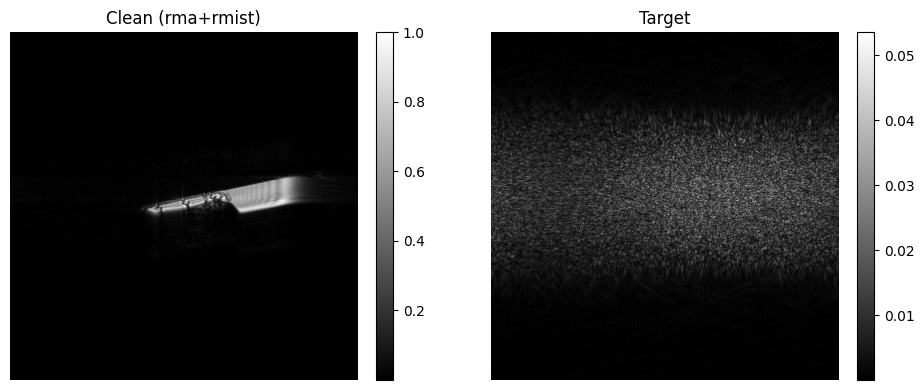

In [38]:
# ============================================================
# 9) CLEAN + TARGET via victim_forward()
# ============================================================
#mode = "rma+rmist"
mode = "rma+rmist"
# ============================================================
# 9) CLEAN + TARGET via victim_forward()
# ============================================================
with torch.no_grad():
    if mode == "rma":
        _, _ = victim_forward(X_v_t, params_torch, mode="rma")
        # For "rma" mode, we define clean_img from rma magnitude for compatibility
        clean_mag, _ = victim_forward(X_v_t, params_torch, mode="rma")
        clean_img = clean_mag.unsqueeze(0).unsqueeze(0)  # (1,1,H,W) placeholder in that case
    else:
        _, _, clean_img = victim_forward(
            X_v_t, params_torch,
            mode="rma+rmist",
            model=model,
            Phi_r_dag=Phi_r_dag,
            do_rms_norm=False
        )  # (1,1,H,W)

global_scale = clean_img.abs().amax() + EPS
clean_img = clean_img / global_scale
#clean_img = clean_img / clean_img.abs().amax() + EPS

# ---- TARGET
if target_mode.lower() == "noise":
    rng = np.random.default_rng(42)
    X_shuf_np = X_v_np.copy()


    #for t in range(Nsamp):
    #    X_shuf_np[t, :] = X_shuf_np[t, rng.permutation(Np)]
    perm = rng.permutation(X_shuf_np.size)   # one global permutation
    X_shuf_np = X_shuf_np.reshape(-1)[perm].reshape(X_shuf_np.shape)

    X_shuf_t = torch.tensor(X_shuf_np, dtype=torch.complex64, device=device)
    
    with torch.no_grad():
        if mode == "rma":
            target_mag, _ = victim_forward(X_shuf_t, params_torch, mode="rma")
            target_img = target_mag.unsqueeze(0).unsqueeze(0)
        else:
            _, _, target_img = victim_forward(
                X_shuf_t, params_torch,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False
            )

    target_img = target_img /global_scale 
    #target_img = target_img /  (target_img.abs().amax() + EPS)

elif target_mode.lower() == "object":
    tgt_path = os.path.join(raw_dataDir, f"{tgt_name}.mat")
    sarRawData_tgt = loadmat(tgt_path)["adcDataCube"]
    Nsamp_t, M_t, N_t = sarRawData_tgt.shape
    Np_t = M_t * N_t

    X_tgt_np = sarRawData_tgt.reshape(Nsamp_t, Np_t).astype(np.complex64)
    X_tgt_t  = torch.tensor(X_tgt_np, dtype=torch.complex64, device=device)

    # target bin pick + overrides (RMA style)
    Echo_t = np.transpose(sarRawData_tgt, (2, 1, 0))
    nFFTtime_t = Echo_t.shape[2]
    rawFFT_t = np.fft.fft(Echo_t, n=nFFTtime_t, axis=2)
    E_t = np.sum(np.sum(np.abs(rawFFT_t)**2, axis=0), axis=0)
    kbin_t_1b = int(np.argmax(E_t) + 1)

    if tgt_name in {"screw_driver", "gun", "rifle"}:
        kbin_t_1b = 8
    if tgt_name == "wrench":
        kbin_t_1b = 7

    z0_t_m = (c0 / 2.0) * (((kbin_t_1b - 1) / (K0 * (1.0 / FS_tgt) * nFFTtime_t)) - tI)

    params_tgt = {
        "Nsamp": Nsamp_t, "M": M_t, "N": N_t,
        "nFFTtime": nFFTtime_t,
        "k0_range_bin": (kbin_t_1b - 1),
        "nFFTspace": nFFTspace,
        "dx": float(dx_t), "dy": float(dy_t),
        "F0": float(F0), "z0": float(z0_t_m),
    }

    print(f"[Target] {tgt_name} | Nsamp={Nsamp_t}, M={M_t}, N={N_t}, Np={Np_t}")
    print(f"[Target] dx={dx_t}, dy={dy_t}, FS={FS_tgt:.0f}, k0_bin={kbin_t_1b}, z0(m)={z0_t_m:.4f}")

    with torch.no_grad():
        if mode == "rma":
            target_mag, _ = victim_forward(X_tgt_t, params_tgt, mode="rma")
            target_img = target_mag.unsqueeze(0).unsqueeze(0)
        else:
            _, _, target_img = victim_forward(
                X_tgt_t, params_tgt,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False
            )
    #target_img = target_img /  target_img.abs().amax() + EPS
    target_img = target_img /global_scale 
else:
    raise ValueError("target_mode must be 'noise' or 'object'")

print("clean_img  |.| min/max:", clean_img.abs().min().item(), "/", clean_img.abs().max().item())
print("target_img |.| min/max:", target_img.abs().min().item(), "/", target_img.abs().max().item())
print("clean_img :", tuple(clean_img.shape), clean_img.dtype, clean_img.device)
print("target_img:", tuple(target_img.shape), target_img.dtype, target_img.device)

# ---- quick visualization
clean2d  = clean_img.detach().abs().squeeze().cpu().numpy()
target2d = target_img.detach().abs().squeeze().cpu().numpy()

clean2d  = np.fliplr(clean2d)
target2d = np.fliplr(target2d)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean2d, cmap="gray", origin="lower")
plt.title("Clean (rma+rmist)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(target2d, cmap="gray", origin="lower")
plt.title("Target")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## random w attack

In [39]:
# ============================================================
# RANDOM-WEIGHT ATTACK SWEEP
# Replaces DIA optimization over A with random complex weights
# ============================================================

import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

EPS = 1e-12

# ------------------------------------------------------------
# User settings for random attack
# ------------------------------------------------------------
num_trials = 20

# Example sweep like MATLAB
candidate_PaPr_dB = [10] #list(range(0, 31))   # [0,1,...,10]

# concealment criterion: lower SSIM(A,C) means stronger concealment
success_ssim_thresh = 0.001

#success_rate_thresh = 0.01

success_rate_thresh = 1

# random weight model:
#   "complex_gaussian" : A ~ CN(0,1)
#   "unit_modulus"     : random phase only
random_weight_mode = "complex_gaussian"

# ------------------------------------------------------------
# Helper: reconstruct attacked image from random A
# ------------------------------------------------------------
def reconstruct_adv_image_random(
    X_v_t,
    D_t,
    A_rand,
    params_torch,
    victim_mode,
    model,
    Phi_r_dag,
    global_scale,
):
    """
    X_v_t : (Nsamp, Np) complex
    D_t   : (Nsamp, Np) complex
    A_rand: (Np,) complex

    returns:
      adv_img   : (1,1,H,W)
      PaPr      : scalar
      PaPr_dB   : scalar
    """
    delta = D_t * A_rand.unsqueeze(0)      # (Nsamp, Np)
    X_adv = X_v_t + delta                  # (Nsamp, Np)

    with torch.no_grad():
        if victim_mode == "rma":
            adv_mag, _ = victim_forward(X_adv, params_torch, mode="rma")
            adv_img = adv_mag.unsqueeze(0).unsqueeze(0)
            adv_img = adv_img / (global_scale + EPS)
        else:
            _, _, adv_img = victim_forward(
                X_adv,
                params_torch,
                mode="rma+rmist",
                model=model,
                Phi_r_dag=Phi_r_dag,
                do_rms_norm=False,
            )
            adv_img = adv_img / (global_scale + EPS)

        Pa = (torch.linalg.norm(delta) ** 2).item()
        Pr = (torch.linalg.norm(X_v_t) ** 2).item() + EPS
        PaPr = Pa / Pr
        PaPr_dB = 10.0 * math.log10(PaPr + EPS)

    return adv_img, PaPr, PaPr_dB


# ------------------------------------------------------------
# Helper: compare adversarial image to clean image
# ------------------------------------------------------------
def compare_to_clean(adv_img, clean_img):
    """
    adv_img, clean_img: (1,1,H,W) torch tensors

    returns:
      mse_AC, ncc_AC, ssim_AC, psnr_AC
    """
    with torch.no_grad():
        mse_AC = F.mse_loss(adv_img, clean_img).item()

        a = adv_img.reshape(-1)
        c = clean_img.reshape(-1)

        ncc_num = torch.sum(a * c)
        ncc_den = torch.sqrt(torch.sum(a**2) * torch.sum(c**2) + EPS)
        ncc_AC = (ncc_num / ncc_den).item()

        adv2d = adv_img.detach().squeeze().cpu().numpy()
        cln2d = clean_img.detach().squeeze().cpu().numpy()

        # MATLAB-like display/metric orientation
        adv2d = np.fliplr(adv2d)
        cln2d = np.fliplr(cln2d)

        data_range_C = float(cln2d.max() - cln2d.min()) + EPS
        ssim_AC = ssim(adv2d, cln2d, data_range=data_range_C)
        psnr_AC = psnr(cln2d, adv2d, data_range=data_range_C)

    return mse_AC, ncc_AC, ssim_AC, psnr_AC


# ------------------------------------------------------------
# Power reference
# ------------------------------------------------------------
Pr_ref = (torch.linalg.norm(X_v_t) ** 2).item() + EPS

print("\n============================================================")
print(f"Random-weight concealment sweep for {victim_mode} on {victim_name}")
print(f"Trials per budget: {num_trials}")
print(f"Success criterion: SSIM(A,C) <= {success_ssim_thresh:.3f}")
print(f"Required success rate: {success_rate_thresh:.2f}")
print("============================================================\n")

all_budget_results = []

best_budget_found = False
chosen_budget_idx = None

# ------------------------------------------------------------
# Sweep over candidate Pa/Pr budgets
# ------------------------------------------------------------
for b_idx, target_PaPr_dB in enumerate(candidate_PaPr_dB):
    target_PaPr = 10 ** (target_PaPr_dB / 10.0)

    psnr_AC_trials = np.zeros(num_trials, dtype=np.float64)
    ssim_AC_trials = np.zeros(num_trials, dtype=np.float64)
    ncc_AC_trials  = np.zeros(num_trials, dtype=np.float64)
    pa_pr_trials   = np.zeros(num_trials, dtype=np.float64)
    mse_AC_trials  = np.zeros(num_trials, dtype=np.float64)

    success_flags = np.zeros(num_trials, dtype=bool)

    adv_imgs_trial = []
    A_store_trial  = []

    print(f"Testing budget Pa/Pr = {target_PaPr_dB:.2f} dB ...")

    for tr in range(num_trials):
        rng_local = np.random.default_rng(10000 + 100 * (b_idx + 1) + (tr + 1))

        # ----------------------------------------------------
        # Draw random complex weights
        # ----------------------------------------------------
        if random_weight_mode.lower() == "complex_gaussian":
            A_re = rng_local.standard_normal(Np)
            A_im = rng_local.standard_normal(Np)
            A_rand_np = A_re + 1j * A_im

        elif random_weight_mode.lower() == "unit_modulus":
            theta = 2 * np.pi * rng_local.random(Np)
            A_rand_np = np.exp(1j * theta)

        else:
            raise ValueError("Unknown random_weight_mode.")

        A_rand = torch.tensor(A_rand_np.astype(np.complex64), device=device)

        # ----------------------------------------------------
        # Scale to satisfy target Pa/Pr
        # ----------------------------------------------------
        delta_rand = D_t * A_rand.unsqueeze(0)
        Pa_rand = (torch.linalg.norm(delta_rand) ** 2).item()
        #scale_pow =1 
        scale_pow = math.sqrt((target_PaPr * Pr_ref) / (Pa_rand + EPS))
        A_rand = A_rand * scale_pow

        # ----------------------------------------------------
        # Reconstruct attacked image
        # ----------------------------------------------------
        adv_img, PaPr_final, _ = reconstruct_adv_image_random(
            X_v_t=X_v_t,
            D_t=D_t,
            A_rand=A_rand,
            params_torch=params_torch,
            victim_mode=victim_mode,
            model=model,
            Phi_r_dag=Phi_r_dag,
            global_scale=global_scale,
        )

        # ----------------------------------------------------
        # Metrics against clean image
        # ----------------------------------------------------
        mse_AC, ncc_AC, ssim_AC, psnr_AC = compare_to_clean(adv_img, clean_img)

        mse_AC_trials[tr] = mse_AC
        ncc_AC_trials[tr] = ncc_AC
        ssim_AC_trials[tr] = ssim_AC
        psnr_AC_trials[tr] = psnr_AC
        pa_pr_trials[tr] = PaPr_final

        success_flags[tr] = (ssim_AC <= success_ssim_thresh)

        adv_imgs_trial.append(adv_img.detach().clone())
        A_store_trial.append(A_rand.detach().clone())

    success_rate = np.mean(success_flags)

    print(f"  PSNR(A,C): {psnr_AC_trials.mean():.2f} ± {psnr_AC_trials.std():.2f} dB")
    print(f"  SSIM(A,C): {ssim_AC_trials.mean():.4f} ± {ssim_AC_trials.std():.4f}")
    print(f"  NCC(A,C) : {ncc_AC_trials.mean():.4f} ± {ncc_AC_trials.std():.4f}")
    print(f"  Pa/Pr    : {pa_pr_trials.mean():.4e} ± {pa_pr_trials.std():.4e} (linear)")
    print(f"  Success rate (SSIM<={success_ssim_thresh:.3f}): {success_rate:.2f}\n")

    result = {
        "PaPr_dB": target_PaPr_dB,
        "PaPr_lin": float(pa_pr_trials.mean()),
        "psnr_AC_mean": float(psnr_AC_trials.mean()),
        "psnr_AC_std": float(psnr_AC_trials.std()),
        "ssim_AC_mean": float(ssim_AC_trials.mean()),
        "ssim_AC_std": float(ssim_AC_trials.std()),
        "ncc_AC_mean": float(ncc_AC_trials.mean()),
        "ncc_AC_std": float(ncc_AC_trials.std()),
        "mse_AC_mean": float(mse_AC_trials.mean()),
        "mse_AC_std": float(mse_AC_trials.std()),
        "success_rate": float(success_rate),
        "adv_imgs": adv_imgs_trial,
        "A_store": A_store_trial,
        "success_flags": success_flags.copy(),
        "psnr_AC_trials": psnr_AC_trials.copy(),
        "ssim_AC_trials": ssim_AC_trials.copy(),
        "ncc_AC_trials": ncc_AC_trials.copy(),
        "pa_pr_trials": pa_pr_trials.copy(),
    }
    all_budget_results.append(result)

    if (not best_budget_found) and (success_rate >= success_rate_thresh):
        best_budget_found = True
        chosen_budget_idx = b_idx

# ------------------------------------------------------------
# Choose operating budget
# ------------------------------------------------------------
if best_budget_found:
    print(f"Chosen smallest successful budget: {all_budget_results[chosen_budget_idx]['PaPr_dB']:.2f} dB")
else:
    chosen_budget_idx = len(all_budget_results) - 1
    print("No budget met success-rate criterion.")
    print(f"Using strongest tested budget: {all_budget_results[chosen_budget_idx]['PaPr_dB']:.2f} dB")

chosen = all_budget_results[chosen_budget_idx]

# Pick median SSIM_AC among successful trials if possible; else best concealment
succ_idx = np.where(chosen["success_flags"])[0]
if len(succ_idx) > 0:
    ord_idx = np.argsort(chosen["ssim_AC_trials"][succ_idx])
    pick = succ_idx[ord_idx[max(0, round(len(ord_idx) / 2) - 1)]]
else:
    pick = int(np.argmin(chosen["ssim_AC_trials"]))

adv_img_best = chosen["adv_imgs"][pick]
A_best       = chosen["A_store"][pick]



Random-weight concealment sweep for rma+rmist on butcher_knife
Trials per budget: 20
Success criterion: SSIM(A,C) <= 0.001
Required success rate: 1.00

Testing budget Pa/Pr = 10.00 dB ...
  PSNR(A,C): 14.07 ± 0.20 dB
  SSIM(A,C): 0.2106 ± 0.0058
  NCC(A,C) : 0.3576 ± 0.0404
  Pa/Pr    : 1.0000e+01 ± 9.8403e-07 (linear)
  Success rate (SSIM<=0.001): 0.00

No budget met success-rate criterion.
Using strongest tested budget: 10.00 dB



FINAL TABLE NUMBERS for rma+rmist on butcher_knife
Use budget: 10.00 dB
PSNR(A,C): 14.07 ± 0.20 dB
SSIM(A,C): 0.2106 ± 0.0058
Pa/Pr     : 10.0000 (linear mean), 10.0000 dB


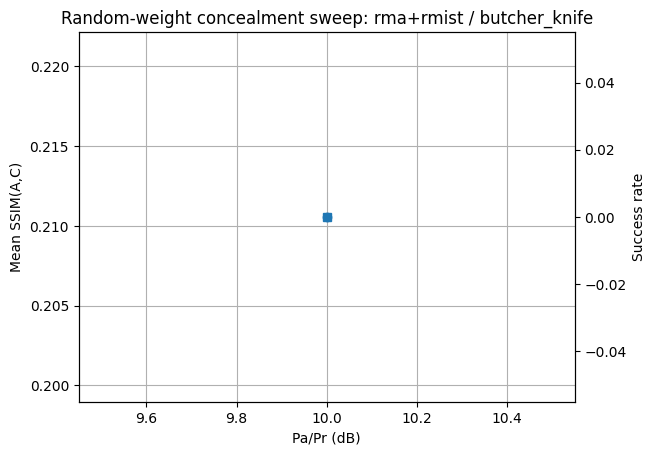

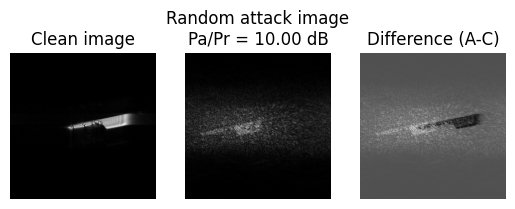

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n============================================================")
print(f"FINAL TABLE NUMBERS for {victim_mode} on {victim_name}")
print(f"Use budget: {chosen['PaPr_dB']:.2f} dB")
print(f"PSNR(A,C): {chosen['psnr_AC_mean']:.2f} ± {chosen['psnr_AC_std']:.2f} dB")
print(f"SSIM(A,C): {chosen['ssim_AC_mean']:.4f} ± {chosen['ssim_AC_std']:.4f}")

PaPr_lin_mean = chosen["PaPr_lin"]
PaPr_dB_mean  = 10.0 * math.log10(PaPr_lin_mean + EPS)
print(f"Pa/Pr     : {PaPr_lin_mean:.4f} (linear mean), {PaPr_dB_mean:.4f} dB")
print("============================================================")

# ============================================================
# BUDGET SWEEP FIGURE
# ============================================================
plt.figure()

xvals = [r["PaPr_dB"] for r in all_budget_results]
ssim_means = [r["ssim_AC_mean"] for r in all_budget_results]
succ_rates = [r["success_rate"] for r in all_budget_results]

ax1 = plt.gca()
ax1.plot(xvals, ssim_means, "-o", linewidth=1.5)
ax1.set_ylabel("Mean SSIM(A,C)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(xvals, succ_rates, "-s", linewidth=1.5)
ax2.set_ylabel("Success rate")

ax1.set_xlabel("Pa/Pr (dB)")
plt.title(f"Random-weight concealment sweep: {victim_mode} / {victim_name}")
plt.show()


# ============================================================
# QUALITATIVE FIGURE
# ============================================================
adv2d = adv_img_best.detach().squeeze().cpu().numpy()
cln2d = clean_img.detach().squeeze().cpu().numpy()

adv2d = np.fliplr(adv2d)
cln2d = np.fliplr(cln2d)

clean2d = np.abs(cln2d)
adv2d_v = np.abs(adv2d)
diff2d  = adv2d_v - clean2d

plt.figure()

plt.subplot(1, 3, 1)
plt.imshow(clean2d, cmap="gray", origin="lower")
plt.title("Clean image")
plt.axis("off")
#plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(adv2d_v, cmap="gray", origin="lower")
plt.title(f"Random attack image\nPa/Pr = {chosen['PaPr_dB']:.2f} dB")
plt.axis("off")
#plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff2d, cmap="gray", origin="lower")
plt.title("Difference (A-C)")
plt.axis("off")
#plt.colorbar()

plt.show()